<a href="https://colab.research.google.com/github/mohaipro/Sentiments_Text/blob/main/sentiment_analysis_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Import the NumPy library for numerical operations
import numpy as np

# Import the pyplot module from matplotlib for plotting and visualization
import matplotlib.pyplot as plt

# Import the pandas library for data manipulation and analysis
import pandas as pd

In [13]:
# Read the CSV file "Tweets.csv" into a pandas DataFrame
df = pd.read_csv("Tweets.csv")

# Display the first five rows of the DataFrame to inspect the data
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [14]:
# Calculate and display the number of samples (rows) in the dataset
num_samples = len(df)

# Calculate and display the number of features (columns), including the target output
num_features = len(df.columns)

# Output the results
print("Number of samples in the dataset:", num_samples)
print("Number of features including:", num_features)

Number of samples in the dataset: 14640
Number of features including: 15


In [15]:
# Calculate the number of unique sentiment classes in the 'airline_sentiment' column
num_classes = len(df["airline_sentiment"].value_counts())

# Display the number of unique sentiment classes
print("number of classes in the dataset:",num_classes)

# Display the count of samples for each sentiment class
print(df["airline_sentiment"].value_counts())

number of classes in the dataset: 3
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [16]:
# Display summary statistics for numerical columns
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [17]:
# See the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [18]:
# Display the number of missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,5462
negativereason_confidence,4118
airline,0
airline_sentiment_gold,14600
name,0
negativereason_gold,14608
retweet_count,0


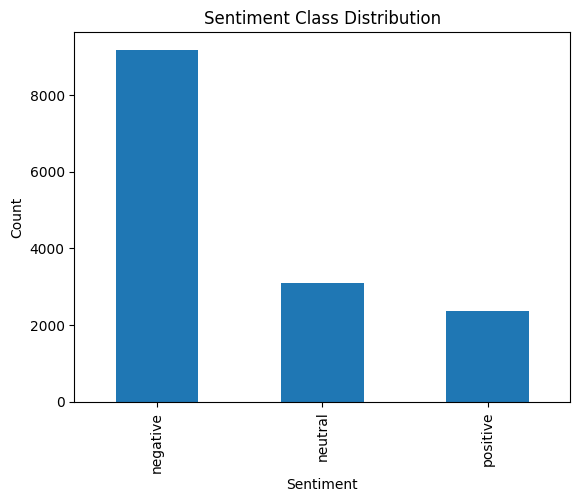

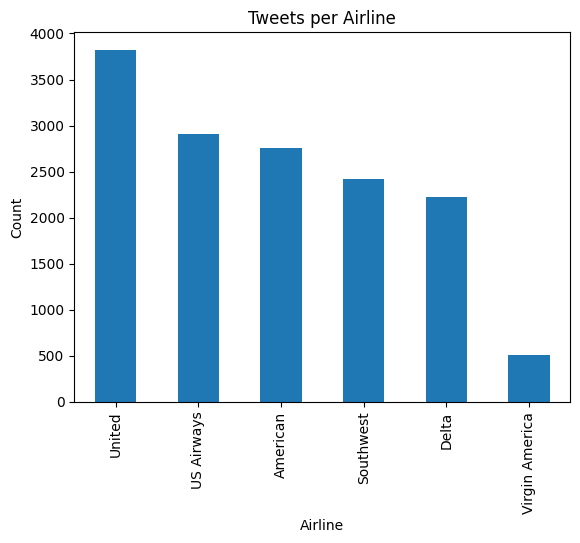

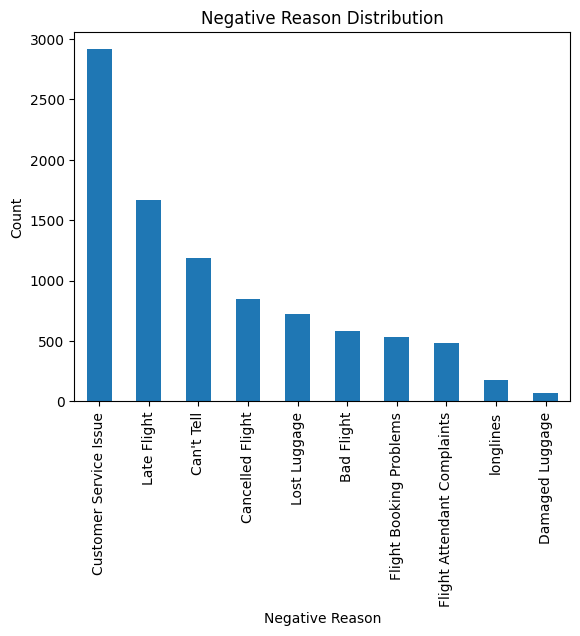

In [19]:
# Visualize the distribution of sentiment classes
df["airline_sentiment"].value_counts().plot(kind='bar', title='Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of tweets per airline
df["airline"].value_counts().plot(kind='bar', title='Tweets per Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of negative reasons (if available)
if df["negativereason"].notnull().any():
    df["negativereason"].value_counts().plot(kind='bar', title='Negative Reason Distribution')
    plt.xlabel('Negative Reason')
    plt.ylabel('Count')
    plt.show()

In [20]:
# Select the 'text' column as the feature set (X) containing the tweet texts
X = df["text"]

# Select the 'airline_sentiment' column as the target variable (y) containing sentiment labels
y = df["airline_sentiment"]

In [21]:
# Display an example tweet and its corresponding sentiment label
# X contains the tweet texts, y contains the sentiment labels

idx = 24

# Show an example of the data we use
print("Example of the data we use:")
print(X[idx])
print()
# Show the corresponding sentiment
print("Corresponding Sentiment:")
print(y[idx])

Example of the data we use:
@VirginAmerica you guys messed up my seating.. I reserved seating with my friends and you guys gave my seat away ... 😡 I want free internet

Corresponding Sentiment:
negative


In [22]:
# Import necessary libraries for text preprocessing and feature extraction
import string  # For handling punctuation
import re      # For regular expressions (used in emoji removal)
import nltk    # Natural Language Toolkit for tokenization
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from nltk.tokenize import word_tokenize

# Download required NLTK data files for tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

def remove_emojis(text):
    """
    Remove emojis from the input text using a regular expression pattern
    that matches a wide range of Unicode emoji characters.
    """
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def preprocess_text(text):
    """
    Preprocess a single tweet by:
    1. Removing emojis.
    2. Lowercasing all text.
    3. Tokenizing the text into words.
    4. Removing punctuation tokens.
    5. Removing English stopwords.
    6. Removing the first token (assumed to be '@VirginAmerica').
    7. Joining the tokens back into a single string.
    """
    # Remove emojis from the text
    text = remove_emojis(text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text into words
    words = word_tokenize(text)
    # Remove punctuation tokens
    words = [word for word in words if word not in string.punctuation]
    # Remove English stopwords
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    # Remove the first token (assumed to be '@VirginAmerica')
    words = words[1:]
    # Join the tokens back into a single string
    return ' '.join(words)

# Apply the preprocessing function to each tweet in the feature set X
X_processed = X.apply(preprocess_text)

# Display the first few preprocessed tweets
X_processed.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text
0,dhepburn said
1,plus 've added commercials experience ... tacky
2,did n't today ... mean need trip
3,'s really aggressive blast obnoxious `` entert...
4,'s really big bad thing


In [23]:
# Select the 31st element from the list or array X as the sample text to preprocess
old_text = X[30]

# Display the original text before preprocessing
print("old text before preprocessing:")
print(old_text)

# Print a separator line for clarity in output
print("#"*75)

# Apply the preprocessing function to the selected text
new_text = preprocess_text(old_text)

# Display the text after preprocessing
print("new text after preprocessing:")
print(new_text)

old text before preprocessing:
@VirginAmerica hi! I just bked a cool birthday trip with you, but i can't add my elevate no. cause i entered my middle name during Flight Booking Problems 😢
###########################################################################
new text after preprocessing:
hi just bked cool birthday trip ca n't add elevate cause entered middle flight booking problems


In [24]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Step 1: Create a LabelEncoder instance
# LabelEncoder is used to convert categorical labels into integer codes.
le = LabelEncoder()

# Step 2: Fit the encoder to the target labels
# 'y' should be a list or array of categorical labels (e.g., strings).
le.fit(y)

# Step 3: Transform the labels to integer codes
# This replaces each unique label in 'y' with an integer.
y_encoded = le.transform(y)

# Step 4: Retrieve the mapping of original labels to encoded integers
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# Step 5: Display the unique encoded labels and their corresponding original labels
unique_encoded_labels = np.unique(y_encoded)
unique_original_labels = le.inverse_transform(unique_encoded_labels)

# Output variables for inspection in the notebook
print(unique_encoded_labels)
print(unique_original_labels)
print(label_mapping)

# Looping through the labels and their corresponding enocding
for i in range(len(unique_encoded_labels)):
    print("The emotion: ", unique_original_labels[i], "has encoding of: ", unique_encoded_labels[i])

[0 1 2]
['negative' 'neutral' 'positive']
{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
The emotion:  negative has encoding of:  0
The emotion:  neutral has encoding of:  1
The emotion:  positive has encoding of:  2


In [25]:
# importing the required Bag of Words Feature Extraction Technique
from sklearn.feature_extraction.text import CountVectorizer

# Assuming X_processed is a list or Series of preprocessed text data
bow = CountVectorizer(max_features=500, ngram_range=(1, 2))

X_transformed = bow.fit_transform(X_processed)

# To view the feature names (vocabulary)
feature_names = bow.get_feature_names_out()

# To convert the sparse matrix to a dense array (optional, for small datasets)
X_transformed_dense = X_transformed.toarray()

In [26]:
# create a dataframe of features
import pandas as pd
df_new = pd.DataFrame(X_transformed_dense, columns=feature_names)
df_new

,10,100,11,12,15,1st,20,200,24,25,...,world,worse,worst,worst airline,worst customer,wow,wrong,year,yes,yesterday
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14636,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
# Display the number of samples (rows) in the feature dataframe
num_samples = len(df_new)

# Display the number of features (columns) in the feature dataframe
num_features = len(df_new.columns)

# Output the results
print(f"(num_samples, num_features) = {(num_samples,num_features)}")

(num_samples, num_features) = (14640, 500)


In [28]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
# - df_new: feature DataFrame
# - y_encoded: encoded target labels
# - test_size=0.2: 20% of data for testing
# - shuffle=True: shuffle data before splitting
# - stratify=y_encoded: maintain label proportions in splits
# - random_state=42: ensure reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    df_new, y_encoded,
    test_size=0.15,
    shuffle=True,
    stratify=y_encoded,
    random_state=42
)

# Display the shape of the training and testing feature sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12444, 500)
X_test shape: (2196, 500)
y_train shape: (12444,)
y_test shape: (2196,)


# Logistic Regression Modeling for NLP

In [29]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr = LogisticRegression()

# Fit the model to the training data
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

In [30]:
# Calculate and display the accuracy scores of the trained Logistic Regression model
# on both the training and testing datasets.
# - model.score(X_train, y_train): returns the mean accuracy on the training data.
# - model.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for Logistic Regression:", lr.score(X_train, y_train))
print("Testing Accuracy Score for Logistic Regression:", lr.score(X_test, y_test))

Training Accuracy Score for Logistic Regression: 0.7807778849244615
Testing Accuracy Score for Logistic Regression: 0.7477231329690346


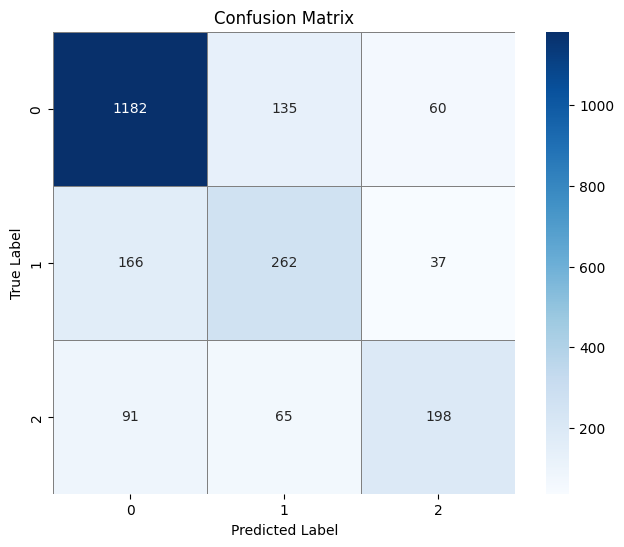

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1377
           1       0.57      0.56      0.57       465
           2       0.67      0.56      0.61       354

    accuracy                           0.75      2196
   macro avg       0.69      0.66      0.67      2196
weighted avg       0.74      0.75      0.74      2196



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred, output_dict=False))

In [55]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained Logistic Regression model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_proba = lr.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred)

print("Categorical Cross Entropy Loss for LR:",log_loss(y_test,y_pred_proba))

[[7.68062155e-01 1.99213763e-01 3.27240820e-02]
 [9.67849216e-01 2.90890584e-02 3.06172585e-03]
 [4.23567145e-01 5.03180295e-01 7.32525599e-02]
 ...
 [2.20700546e-01 7.21422665e-01 5.78767892e-02]
 [3.91659871e-01 4.54540056e-01 1.53800073e-01]
 [9.88303407e-01 1.15783510e-02 1.18241930e-04]]
[0 0 1 ... 1 1 0]
[0 0 1 ... 1 1 0]
Categorical Cross Entropy Loss for LR: 0.5929102628930075


# K Nearest Neighbor Modeling for NLP

In [34]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN classifier
knn = KNeighborsClassifier()

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test)

In [35]:
# Calculate and display the accuracy scores of the trained KNN model
# on both the training and testing datasets.
# - knn.score(X_train, y_train): returns the mean accuracy on the training data.
# - knn.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for K Nearest Neighbor:", knn.score(X_train, y_train))
print("Testing Accuracy Score for K Nearest Neighbor:", knn.score(X_test, y_test))

Training Accuracy Score for K Nearest Neighbor: 0.7520893603342976
Testing Accuracy Score for K Nearest Neighbor: 0.6347905282331512


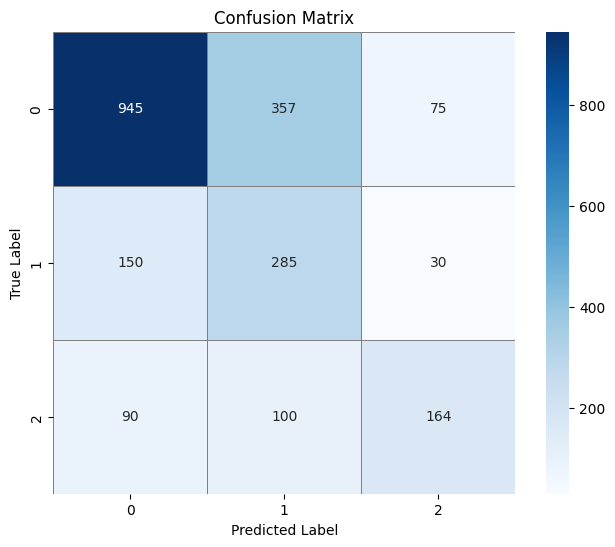

              precision    recall  f1-score   support

           0       0.80      0.69      0.74      1377
           1       0.38      0.61      0.47       465
           2       0.61      0.46      0.53       354

    accuracy                           0.63      2196
   macro avg       0.60      0.59      0.58      2196
weighted avg       0.68      0.63      0.65      2196



In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred_knn, output_dict=False))

In [56]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained KNN model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_knn_proba = knn.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_knn_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_knn_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred_knn)

print("Categorical Cross Entropy for KNN:",log_loss(y_test, y_pred_knn_proba))

[[0.8 0.  0.2]
 [0.4 0.2 0.4]
 [0.4 0.4 0.2]
 ...
 [0.  1.  0. ]
 [0.4 0.6 0. ]
 [0.8 0.2 0. ]]
[0 0 0 ... 1 1 0]
[0 0 0 ... 1 1 0]
Categorical Cross Entropy for KNN: 3.9896126241110688


# Support Vector Machine Modeling for NLP

In [62]:
from sklearn.svm import SVC

# Create the Support Vector Machine (SVM) model
svm = SVC(probability=True)

# Fit the model to the training data
svm.fit(X_train, y_train)

# Predict on the test set
y_pred_svm = svm.predict(X_test)

In [63]:
# Calculate and display the accuracy scores of the trained SVM model
# on both the training and testing datasets.
# - svm.score(X_train, y_train): returns the mean accuracy on the training data.
# - svm.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for SVM:", svm.score(X_train, y_train))
print("Testing Accuracy Score for SVM:", svm.score(X_test, y_test))

Training Accuracy Score for SVM: 0.8409675345548056
Testing Accuracy Score for SVM: 0.7577413479052824


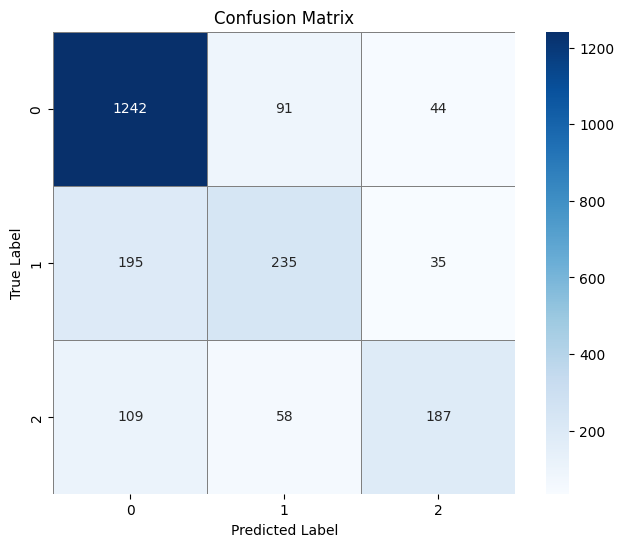

              precision    recall  f1-score   support

           0       0.80      0.90      0.85      1377
           1       0.61      0.51      0.55       465
           2       0.70      0.53      0.60       354

    accuracy                           0.76      2196
   macro avg       0.71      0.65      0.67      2196
weighted avg       0.75      0.76      0.75      2196



In [64]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred_svm, output_dict=False))

In [65]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained SVM model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_svm_proba = svm.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_svm_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_svm_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred_svm)

print("Categorical Cross Entropy for KNN:",log_loss(y_test, y_pred_svm_proba))

[[0.87304161 0.10659883 0.02035956]
 [0.8872974  0.0782189  0.03448371]
 [0.4650317  0.48578409 0.04918421]
 ...
 [0.14726604 0.78010718 0.07262678]
 [0.41816729 0.51819217 0.06364054]
 [0.95512905 0.03819924 0.00667171]]
[0 0 1 ... 1 1 0]
[0 0 0 ... 1 1 0]
Categorical Cross Entropy for KNN: 0.609598163927524


# XGBOOST Modeling for NLP

In [45]:
from xgboost import XGBClassifier

# Create the XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Fit the model to the training data
xgb.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:26:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [47]:
# Calculate and display the accuracy scores of the trained XGB model
# on both the training and testing datasets.
# - svm.score(X_train, y_train): returns the mean accuracy on the training data.
# - svm.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for XGB:", xgb.score(X_train, y_train))
print("Testing Accuracy Score for XGB:", xgb.score(X_test, y_test))

Training Accuracy Score for XGB: 0.7867245258759241
Testing Accuracy Score for XGB: 0.7304189435336976


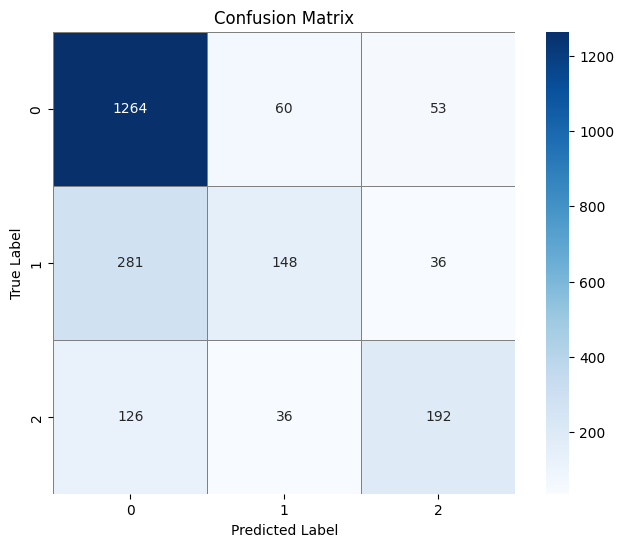

              precision    recall  f1-score   support

           0       0.76      0.92      0.83      1377
           1       0.61      0.32      0.42       465
           2       0.68      0.54      0.60       354

    accuracy                           0.73      2196
   macro avg       0.68      0.59      0.62      2196
weighted avg       0.71      0.73      0.71      2196



In [54]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred_xgb, output_dict=False))

In [53]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained KNN model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_xgb_proba = xgb.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_xgb_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_xgb_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred_xgb)

print("Categorical Cross Entropy:",log_loss(y_test, y_pred_xgb_proba))

[[0.7998578  0.15738855 0.04275359]
 [0.86966413 0.09856146 0.03177437]
 [0.4638654  0.4220475  0.11408706]
 ...
 [0.28496307 0.64995235 0.06508458]
 [0.47200406 0.39527133 0.13272461]
 [0.98431647 0.01463314 0.00105031]]
[0 0 0 ... 1 0 0]
[0 0 0 ... 1 0 0]
Categorical Cross Entropy: 0.6040768884100404


# Documenting the Results of All Machine Learning Models

In [79]:
testing_logloss_lr = log_loss(y_test, y_pred_proba)
testing_logloss_knn = log_loss(y_test, y_pred_knn_proba)
testing_logloss_svm = log_loss(y_test, y_pred_svm_proba)
testing_logloss_xgb = log_loss(y_test, y_pred_xgb_proba)

testing_accuracy_lr = lr.score(X_test, y_test)
testing_accuracy_knn = knn.score(X_test, y_test)
testing_accuracy_svm = svm.score(X_test, y_test)
testing_accuracy_xgb = xgb.score(X_test, y_test)

df_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM", "XGB"],
    "Accuracy": [testing_accuracy_lr, testing_accuracy_knn, testing_accuracy_svm, testing_accuracy_xgb],
    "LogLoss": [testing_logloss_lr, testing_logloss_knn, testing_logloss_svm, testing_logloss_xgb]
})

,Model,Accuracy,LogLoss
0,Logistic Regression,0.747723,0.592910
1,KNN,0.634791,3.989613
2,SVM,0.757741,0.609598
3,XGB,0.730419,0.604077


In [95]:
print("Models Performance Results on TestingSet Acc&Loss")
print("#"*50)
print(df_results.to_string(index=False).upper())
print("#"*50)

Models Performance Results on TestingSet Acc&Loss
##################################################
              MODEL  ACCURACY  LOGLOSS
LOGISTIC REGRESSION  0.747723 0.592910
                KNN  0.634791 3.989613
                SVM  0.757741 0.609598
                XGB  0.730419 0.604077
##################################################


# Mapping and Real-Time Simulation for Sentiment Analysis

In [66]:
# Display the classes found by the label encoder
print(le.classes_)

# Print each class and its corresponding encoded label
for i, cls in enumerate(le.classes_):
    print("cls:", cls, "has label ->", i)

# Mapping from label indices to emotion categories
l2emotion = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Display the mapping from emotion category to label index (assumed to be defined elsewhere)
emotion2label = {
    "negative":0,
    "neutral":1,
    "posotive":2
}

['negative' 'neutral' 'positive']
cls: negative has label -> 0
cls: neutral has label -> 1
cls: positive has label -> 2


In [76]:
def program_nlp(text: str, model) -> str:
    preprocessed_text = preprocess_text(text)
    # Wrap preprocessed_text in a list to make it iterable
    features_extracted = bow.transform([preprocessed_text])
    output = model.predict(features_extracted)
    # output is an array of label indices, so output[0] is the predicted label index
    return l2emotion[output[0]]

text = "I am so happy to expericne this travel. it was so good and awesome"
out = program_nlp(text, lr)
print("Sentiment Detected:".upper(),out.upper())

SENTIMENT DETECTED: POSITIVE


In [97]:
# Simple chatbot using program_nlp to detect emotion from user input
while True:
    user_input = input("Tell me your opinion (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Goodbye! and See you again")
        break
    emotion = program_nlp(user_input, lr)
    print(f"Your emotion is: {emotion}")

Tell me your opinion (or type 'exit' to quit): I am going to recommend this product so much to my family and friends. This product is really good and comes with high quality material. I love it and I am so happy to have that experience.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Your emotion is: positive
Tell me your opinion (or type 'exit' to quit): No It it very disappointing and not good quality at all. I am not going to try this site again in the future and I will delete my account from the website. Please do not try to reach me and call me ok!
Your emotion is: negative
Tell me your opinion (or type 'exit' to quit): The medical center was amazing, the service was good and the medical stadd were amazing and helpful. The quality of the service was outstanding and doctors are professional and do care for the patients.
Your emotion is: positive
Tell me your opinion (or type 'exit' to quit): I am not at the mood to talk now!
Your emotion is: negative
Tell me your opinion (or type 'exit' to quit): exit
Goodbye! and See you again
